# ITT Pulmon de Oriente — Cali
## Indice de Transformacion Territorial · 5 Dimensiones · 2023-2025
---
**Zona:** Pulmon de Oriente (zona agregada, multiples comunas)  
**Normalizacion:** ref_min / ref_max fijos por indicador (juicio experto)  
**Dimensiones:** Seguridad (30%) · Movilidad (25% ref) · Entorno Urbano (20% ref) · Educ y Des (13% ref) · Cohesion Social (12%)  
**Periodo:** 2023 - 2025

**Datos reales:** Homicidios, Hurtos (ZIP 2026), VIF (ZIP 2025)  
**Referentes:** Movilidad=35.0, Entorno Urbano=39.2, Educacion=54.9, Vulnerabilidad=54.1, Rinas=23.6


## Celda 1 — Instalacion de dependencias


In [2]:
import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
for p in ['geopandas','pyproj','shapely','openpyxl','seaborn','folium']: check_pkg(p)
print('Dependencias verificadas')


Dependencias verificadas


## Celda 2 — Importaciones y configuracion


In [3]:
import json, os, re, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
warnings.filterwarnings('ignore')

C_SEG='#1B4F8A'; C_MOV='#E8852A'; C_COH='#7B1FA2'; C_ITT='#2E7D32'; BG='#F4F6F9'
NIVEL_COLORS = {'Emergencia':'#E53935','Consolidacion':'#FB8C00','Avance':'#43A047','Transformacion':'#1E88E5'}
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':'white','font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
print('Configuracion visual lista')


Configuracion visual lista


In [19]:
##--tener en cuenta
!pwd  ##ignor
!ls /content
!find /content -maxdepth 3 -type d -iname "*itt*"

/content/itt_repos_cali
itt_pulmon_oriente_heatmap_seguridad_trimestral.png  Pulmon_De_Oriente_2026
ITT_Pulmon_Oriente_Seguridad_T1_2026.xlsx	     sample_data
itt_repos_cali
/content/itt_repos_cali
/content/itt_repos_cali/data/itt_roosevelt
/content/itt_repos_cali/data/itt_barrio_obrero
/content/itt_repos_cali/data/itt_avenida_ciudad_de_cali
/content/itt_repos_cali/data/itt_pulmon_oriente
/content/itt_repos_cali/outputs/itt_roosevelt
/content/itt_repos_cali/outputs/itt_barrio_obrero
/content/itt_repos_cali/outputs/IMAGENES_POR_ITT
/content/itt_repos_cali/outputs/itt_avenida_ciudad_de_cali


In [20]:
##--tener en cuenta: clona el fork actualizado (branch jorge_itt)
import os, subprocess
os.chdir('/content')
subprocess.getoutput('rm -rf itt_repos_cali')
print(subprocess.getoutput('git clone -b jorge_itt https://github.com/j0rg3c45/Itt_repos_cali.git itt_repos_cali'))

Cloning into 'itt_repos_cali'...


## Celda 3A — Clone del repo y descompresion (Colab)


In [21]:
##--Clone del fork (solo Colab). En local se salta.
import os, subprocess, zipfile, platform
from pathlib import Path

if platform.system() == "Linux" and os.path.exists("/content"):
    os.chdir("/content")
    subprocess.getoutput("rm -rf itt_repos_cali")
    print(subprocess.getoutput("git clone -b jorge_itt https://github.com/j0rg3c45/Itt_repos_cali.git itt_repos_cali"))
    DATA_DIR = Path("/content/itt_repos_cali/data/itt_pulmon_oriente")
    for zf in sorted(DATA_DIR.glob("*.zip")):
        print(f"Descomprimiendo {zf.name}...")
        with zipfile.ZipFile(zf, "r") as z:
            z.extractall(DATA_DIR)
        print(f"  OK {zf.name}")
else:
    print("Saltando: esta celda solo aplica en Colab. En local los ZIPs deben estar descomprimidos.")


Cloning into 'itt_repos_cali'...
Descomprimiendo Pulmon_De_Oriente_2025.zip...
  OK Pulmon_De_Oriente_2025.zip
Descomprimiendo Pulmon_De_Oriente_2026.zip...
  OK Pulmon_De_Oriente_2026.zip


## Celda 3 — Parametros, rutas y umbrales ref_min / ref_max
Los umbrales estan calibrados para zona grande (>100K hab) segun la guia metodologica.  
Se combinan datos del ZIP 2025 (VIF, poligono, arboles, sedes, CAI) y ZIP 2026 (homicidios, hurtos).


In [22]:
import os, re
from pathlib import Path

# Detectar entorno: Colab o local
if os.path.exists('/content'):
    DATA_DIR = Path('/content/itt_repos_cali/data/itt_pulmon_oriente')
    IMG_DIR = '/content/itt_repos_cali/outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/'
else:
    DATA_DIR = Path(os.getcwd()) / '..' / 'data' / 'itt_pulmon_oriente'
    # En local: descomprimir si hace falta
    import zipfile as _zf
    for _zip in DATA_DIR.glob("*.zip"):
        _target = DATA_DIR / _zip.stem
        if not _target.exists():
            print(f"Descomprimiendo {_zip.name}...")
            with _zf.ZipFile(_zip, "r") as z:
                z.extractall(DATA_DIR)
    IMG_DIR = os.path.join(os.getcwd(), '..', 'outputs', 'IMAGENES_POR_ITT', 'itt_pulmon_oriente') + os.sep

os.makedirs(IMG_DIR, exist_ok=True)
print(f'DATA_DIR: {DATA_DIR}')
print(f'IMG_DIR:  {IMG_DIR}')

# Busqueda flexible de archivos
def find_file(base_dir, pattern):
    regex = re.compile(pattern, re.IGNORECASE)
    for root, _dirs, files in os.walk(base_dir):
        for f in files:
            if regex.search(f) and f.lower().endswith('.geojson'):
                return os.path.join(root, f)
    return None

PATHS = {
    'homicidios': find_file(DATA_DIR, r'homicidios.*2026|DATIC_homicidios'),
    'hurtos':     find_file(DATA_DIR, r'hurtos.*2026|DATIC_hurtos'),
    'vif':        find_file(DATA_DIR, r'VIOLENCIA_INTRAFAMILIAR|DATIC_violencia_intrafamiliar'),
    'poligono':   find_file(DATA_DIR, r'poligonos\.geojson'),
    'arboles':    find_file(DATA_DIR, r'ARBOLES'),
    'sedes':      find_file(DATA_DIR, r'Sedes_educativas'),
    'cai':        find_file(DATA_DIR, r'CAI_MECAL'),
}

ANIOS = [2023, 2024, 2025]
ZONA_NOMBRE = 'Pulmon de Oriente — Cali'

# PESOS por dimension (deben sumar 1.0)
PESOS = {
    'Seguridad': 0.30, 'Movilidad': 0.25,
    'EntornoU':  0.20, 'EducDes':   0.13, 'Cohesion':  0.12,
}

# REFS trimestrales para zona grande (guia metodologica seccion 4.1)
REFS = {
    #                  ref_min  ref_max  inverso  descripcion
    'homicidios':     (5,       50,      True,    'Homicidios trimestrales (zona grande)'),
    'hurtos':         (200,     450,     True,    'Hurtos trimestrales (zona grande)'),
    'vif':            (60,      200,     True,    'VIF trimestral (zona grande)'),
}

# Referentes provisionales (dimensiones sin datos propios completos)
REF_MOVILIDAD      = 35.0   # Score Movilidad Pulmon de Oriente T4-2025
REF_ENTORNO_U      = 39.2   # Score Entorno Urbano
REF_EDUC_DES       = 54.9   # Score Educacion y Desarrollo
REF_VULNERABILIDAD = 54.1   # Concentracion vulnerabilidad
REF_RINAS          = 23.6   # Score Rinas (no hay comparendos en ZIPs)

# Verificar archivos
print('\nArchivos encontrados:')
for n, r in PATHS.items():
    ok = r is not None and os.path.exists(r)
    print(f'  {chr(9989) if ok else chr(10060)}  {n:12s}: {r}')

print(f'\nPeriodo: {ANIOS[0]}-{ANIOS[-1]}')
print('Pesos:', ' | '.join(f'{k}={v:.0%}' for k,v in PESOS.items()))
print('\nUmbrales ref_min / ref_max:')
for ind, (rmin, rmax, inv, desc) in REFS.items():
    print(f'  {ind:12s}  [{rmin:>4} - {rmax:>4}]  inv={inv}  | {desc}')
print(f'\nReferentes: Movilidad={REF_MOVILIDAD}, EntornoU={REF_ENTORNO_U}, EducDes={REF_EDUC_DES}')


DATA_DIR: /content/itt_repos_cali/data/itt_pulmon_oriente
IMG_DIR:  /content/itt_repos_cali/outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/

Archivos encontrados:
  ✅  homicidios  : /content/itt_repos_cali/data/itt_pulmon_oriente/Pulmon_De_Oriente_2026/DATIC_homicidios_2023_2026T1.geojson
  ✅  hurtos      : /content/itt_repos_cali/data/itt_pulmon_oriente/Pulmon_De_Oriente_2026/DATIC_hurtos_2023_2026T1_Pulmon_O.geojson
  ✅  vif         : /content/itt_repos_cali/data/itt_pulmon_oriente/Pulmon_De_Oriente_2025/VIOLENCIA_INTRAFAMILIAR_2023_2025_PULMON.geojson
  ✅  poligono    : /content/itt_repos_cali/data/itt_pulmon_oriente/Pulmon_De_Oriente_2025/poligonos.geojson
  ✅  arboles     : /content/itt_repos_cali/data/itt_pulmon_oriente/Pulmon_De_Oriente_2025/ARBOLES_PULMON.geojson
  ✅  sedes       : /content/itt_repos_cali/data/itt_pulmon_oriente/Pulmon_De_Oriente_2025/Sedes_educativas_oficiales_PULMON_1K.geojson
  ✅  cai         : /content/itt_repos_cali/data/itt_pulmon_oriente/Pulmon_De_Oriente_2

## Celda 4 — Carga de datos


In [23]:
def load_gj(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

raw_hom = load_gj(PATHS['homicidios'])
raw_hur = load_gj(PATHS['hurtos'])
raw_vif = load_gj(PATHS['vif'])

# Datos estaticos / apoyo (opcionales)
raw_arb = load_gj(PATHS['arboles']) if PATHS['arboles'] else {'features': []}
raw_sed = load_gj(PATHS['sedes']) if PATHS['sedes'] else {'features': []}
raw_cai = load_gj(PATHS['cai']) if PATHS['cai'] else {'features': []}

# Poligono de la zona
if PATHS['poligono']:
    gdf_zona = gpd.read_file(PATHS['poligono'])
    gdf_zona_wgs = gdf_zona.to_crs('EPSG:4326')
else:
    gdf_zona = None; gdf_zona_wgs = None

print('Registros cargados:')
for n, r in [('Homicidios', raw_hom), ('Hurtos', raw_hur), ('VIF', raw_vif),
             ('Arboles', raw_arb), ('Sedes', raw_sed), ('CAI', raw_cai)]:
    print(f'  {n:12s}: {len(r["features"]):>6} registros')


Registros cargados:
  Homicidios  :   3284 registros
  Hurtos      :   5171 registros
  VIF         :   1502 registros
  Arboles     :  20472 registros
  Sedes       :     68 registros
  CAI         :      3 registros


## Celda 5 — Mapa de geolocalizacion


In [36]:
if gdf_zona_wgs is not None and not gdf_zona_wgs.empty:
    centroid = gdf_zona_wgs.unary_union.centroid
    m = folium.Map(location=[centroid.y, centroid.x], zoom_start=13, tiles='CartoDB positron')
    folium.GeoJson(gdf_zona_wgs.__geo_interface__, name='Poligono Pulmon de Oriente',
        style_function=lambda x: {'fillColor':'#2E7D32','color':'#1B4F8A','weight':2,'fillOpacity':0.1}).add_to(m)
    folium.LayerControl().add_to(m)
    display(m)
else:
    print('No hay poligono disponible para mapa')


## Celda 6 — Procesamiento de indicadores


In [25]:
FECHA_CANDIDATES = ['fechah', 'fecha_hech', 'fecha_hecho', 'fecha', 'FECHA_HECH']

def pick_col(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def procesar(raw, nombre):
    df = pd.DataFrame([f['properties'] for f in raw['features']])
    col_fecha = pick_col(df, FECHA_CANDIDATES)
    if col_fecha is None:
        raise ValueError(f'No se encontro columna de fecha en {nombre}')
    df['_fecha'] = pd.to_datetime(df[col_fecha], errors='coerce')
    df['año'] = df['_fecha'].dt.year
    df['trimestre'] = df['_fecha'].dt.quarter
    df = df.dropna(subset=['año'])
    df['año'] = df['año'].astype(int)
    return df[df['año'].isin(ANIOS)].copy()

def agg_anual(df):
    return df.groupby('año').size().reindex(ANIOS, fill_value=0)

def agg_trim(df):
    idx = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
    return df.groupby(['año','trimestre']).size().reindex(idx, fill_value=0)

df_hom = procesar(raw_hom, 'Homicidios')
df_hur = procesar(raw_hur, 'Hurtos')
df_vif = procesar(raw_vif, 'VIF')

# Tabla anual
base = pd.DataFrame({'año': ANIOS})
for nombre, df_src in [('homicidios', df_hom), ('hurtos', df_hur), ('vif', df_vif)]:
    base[nombre] = agg_anual(df_src).values

# Tabla trimestral
idx_t = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
corr_trim = pd.DataFrame(index=idx_t).reset_index()
for nombre, df_src in [('homicidios', df_hom), ('hurtos', df_hur), ('vif', df_vif)]:
    ser = agg_trim(df_src).reset_index()
    ser.columns = ['año','trimestre',nombre]
    corr_trim = corr_trim.merge(ser, on=['año','trimestre'], how='left').fillna({nombre: 0})
corr_trim['periodo'] = corr_trim['año'].astype(str) + '-Q' + corr_trim['trimestre'].astype(str)

print('Indicadores anuales:')
print(base.to_string(index=False))
print('\nIndicadores trimestrales:')
print(corr_trim.to_string(index=False))


Indicadores anuales:
 año  homicidios  hurtos  vif
2023        1013    1452  457
2024         938    1409  483
2025        1062    1146  562

Indicadores trimestrales:
 año  trimestre  homicidios  hurtos  vif periodo
2023          1         257     434  106 2023-Q1
2023          2         258     376  138 2023-Q2
2023          3         255     381  125 2023-Q3
2023          4         243     261   88 2023-Q4
2024          1         199     377   98 2024-Q1
2024          2         226     355  123 2024-Q2
2024          3         265     349  136 2024-Q3
2024          4         248     328  126 2024-Q4
2025          1         254     288  126 2025-Q1
2025          2         243     307  142 2025-Q2
2025          3         253     291  189 2025-Q3
2025          4         312     260  105 2025-Q4


## Celda 7 — Normalizacion con ref_min / ref_max e ITT
Normaliza indicadores **trimestralmente** con umbrales fijos. El ITT anual es el promedio de los 4 trimestres.  
Movilidad, Entorno Urbano y Educacion usan referentes provisionales.


In [26]:
def score_ref(valor, ref_min, ref_max, inverso):
    if ref_max == ref_min: return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

# Scores trimestrales por indicador
for ind, (rmin, rmax, inv, desc) in REFS.items():
    corr_trim[f'score_{ind}'] = corr_trim[ind].apply(lambda v, rm=rmin, rx=rmax, i=inv: score_ref(v, rm, rx, i))

# Scores trimestrales por dimension
corr_trim['score_seguridad'] = (corr_trim['score_homicidios'] + corr_trim['score_hurtos']) / 2
corr_trim['score_cohesion']  = (corr_trim['score_vif'] + REF_RINAS + REF_VULNERABILIDAD) / 3
corr_trim['score_movilidad'] = REF_MOVILIDAD
corr_trim['score_entorno_u'] = REF_ENTORNO_U
corr_trim['score_educ_des']  = REF_EDUC_DES

corr_trim['ITT'] = (
    PESOS['Seguridad'] * corr_trim['score_seguridad'] +
    PESOS['Movilidad'] * corr_trim['score_movilidad'] +
    PESOS['EntornoU']  * corr_trim['score_entorno_u'] +
    PESOS['EducDes']   * corr_trim['score_educ_des'] +
    PESOS['Cohesion']  * corr_trim['score_cohesion']
)

def clasificar(v):
    if v < 40: return 'Emergencia'
    elif v < 60: return 'Consolidacion'
    elif v < 80: return 'Avance'
    else: return 'Transformacion'

corr_trim['nivel'] = corr_trim['ITT'].apply(clasificar)

# Scores anuales = promedio de trimestres
base = corr_trim.groupby('año').agg({
    'homicidios': 'sum', 'hurtos': 'sum', 'vif': 'sum',
    'score_seguridad': 'mean', 'score_cohesion': 'mean',
    'score_movilidad': 'mean', 'score_entorno_u': 'mean', 'score_educ_des': 'mean',
    'ITT': 'mean'
}).reset_index()
base['nivel'] = base['ITT'].apply(clasificar)

print('ITT Pulmon de Oriente — Normalizacion con ref_min/ref_max fijos')
print(f'\nReferentes: Movilidad={REF_MOVILIDAD}, EntornoU={REF_ENTORNO_U}, EducDes={REF_EDUC_DES}')
print('\nScores por dimension e ITT (anual = promedio trimestral):')
print(base[['año','score_seguridad','score_movilidad','score_cohesion','score_entorno_u','score_educ_des','ITT','nivel']].round(1).to_string(index=False))


ITT Pulmon de Oriente — Normalizacion con ref_min/ref_max fijos

Referentes: Movilidad=35.0, EntornoU=39.2, EducDes=54.9

Scores por dimension e ITT (anual = promedio trimestral):
 año  score_seguridad  score_movilidad  score_cohesion  score_entorno_u  score_educ_des  ITT      nivel
2023             17.4             35.0            46.3             39.2            54.9 34.5 Emergencia
2024             19.6             35.0            44.8             39.2            54.9 35.0 Emergencia
2025             32.7             35.0            40.1             39.2            54.9 38.3 Emergencia


## Celda 8 — Cards de metricas clave


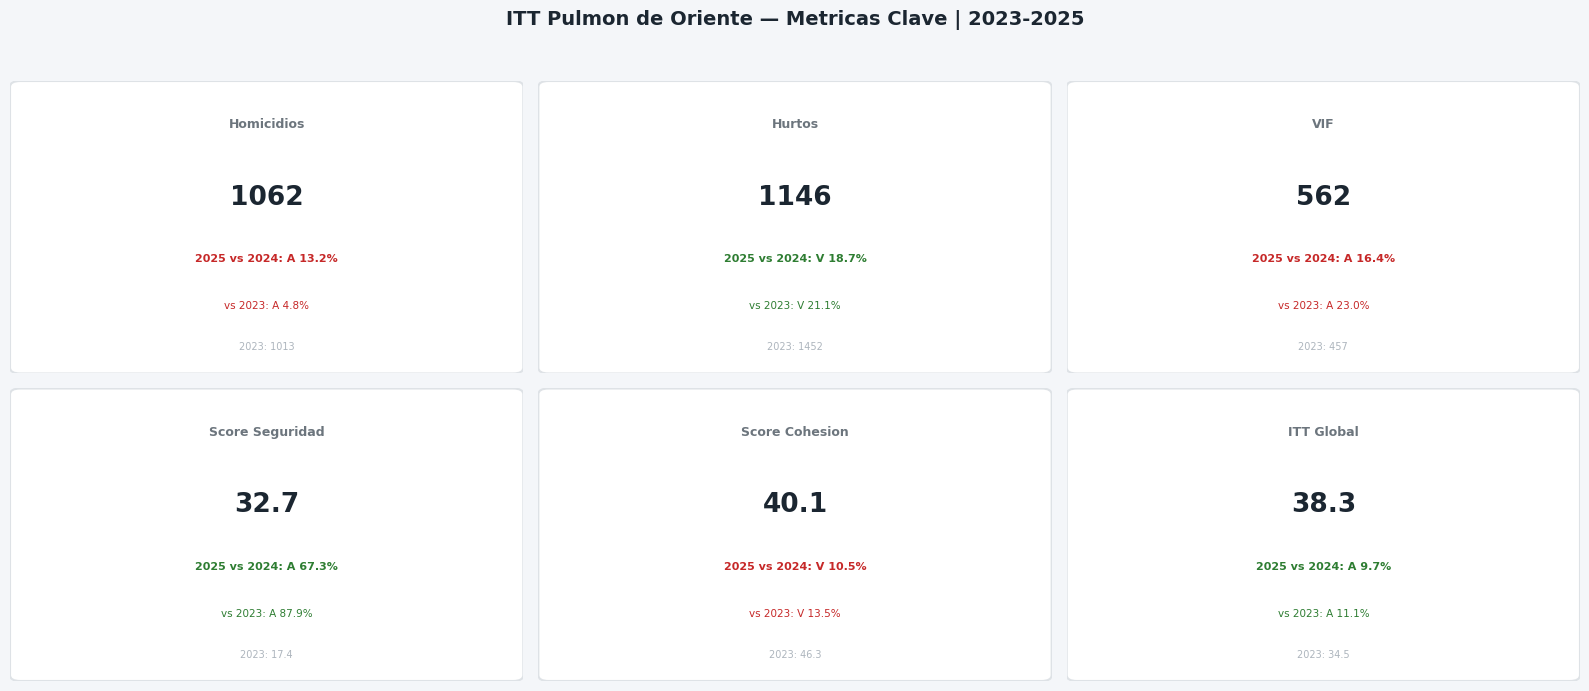

In [27]:
def safe_pct(new, old):
    if old == 0: return 0.0
    return (new - old) / old * 100

def arrow(pct, inv=True):
    if abs(pct) < 1: return 'Sin cambio', 'gray'
    if inv: return (f'V {abs(pct):.1f}%', '#2E7D32') if pct < 0 else (f'A {abs(pct):.1f}%', '#C62828')
    else: return (f'A {abs(pct):.1f}%', '#2E7D32') if pct > 0 else (f'V {abs(pct):.1f}%', '#C62828')

año_ini, año_ant, año_ult = ANIOS[0], ANIOS[-2], ANIOS[-1]
d_ini = base[base['año']==año_ini].iloc[0]
d_ant = base[base['año']==año_ant].iloc[0]
d_ult = base[base['año']==año_ult].iloc[0]

cards = [
    ('Homicidios', int(d_ini['homicidios']), int(d_ant['homicidios']), int(d_ult['homicidios']), True),
    ('Hurtos', int(d_ini['hurtos']), int(d_ant['hurtos']), int(d_ult['hurtos']), True),
    ('VIF', int(d_ini['vif']), int(d_ant['vif']), int(d_ult['vif']), True),
    ('Score Seguridad', d_ini['score_seguridad'], d_ant['score_seguridad'], d_ult['score_seguridad'], False),
    ('Score Cohesion', d_ini['score_cohesion'], d_ant['score_cohesion'], d_ult['score_cohesion'], False),
    ('ITT Global', d_ini['ITT'], d_ant['ITT'], d_ult['ITT'], False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), facecolor=BG)
fig.suptitle(f'ITT Pulmon de Oriente — Metricas Clave | {año_ini}-{año_ult}',
             fontsize=14, fontweight='bold', color='#1B2631', y=0.98)
for i, (titulo, v_ini, v_ant, v_ult, inv) in enumerate(cards):
    ax = axes[i//3][i%3]; ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    rect = mpatches.FancyBboxPatch((0.02,0.02),0.96,0.96, boxstyle='round,pad=0.02',
        linewidth=1.5, edgecolor='#DEE2E6', facecolor='white')
    ax.add_patch(rect)
    ax.text(0.5,0.85, titulo, ha='center', va='center', fontsize=9, color='#6C757D', fontweight='bold')
    val_d = f'{v_ult:.1f}' if isinstance(v_ult,float) else str(v_ult)
    ax.text(0.5,0.60, val_d, ha='center', va='center', fontsize=19, fontweight='bold', color='#1B2631')
    pct1 = safe_pct(v_ult, v_ant)
    ar1, col1 = arrow(pct1, inv)
    ax.text(0.5,0.38, f'{año_ult} vs {año_ant}: {ar1}', ha='center', fontsize=8, color=col1, fontweight='bold')
    pct2 = safe_pct(v_ult, v_ini)
    ar2, col2 = arrow(pct2, inv)
    ax.text(0.5,0.22, f'vs {año_ini}: {ar2}', ha='center', fontsize=7.5, color=col2)
    ref = f'{v_ini:.1f}' if isinstance(v_ini,float) else str(v_ini)
    ax.text(0.5,0.08, f'{año_ini}: {ref}', ha='center', fontsize=7, color='#ADB5BD')

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig(IMG_DIR + 'itt_pulmon_cards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 9 — Heatmap: Dimension Seguridad


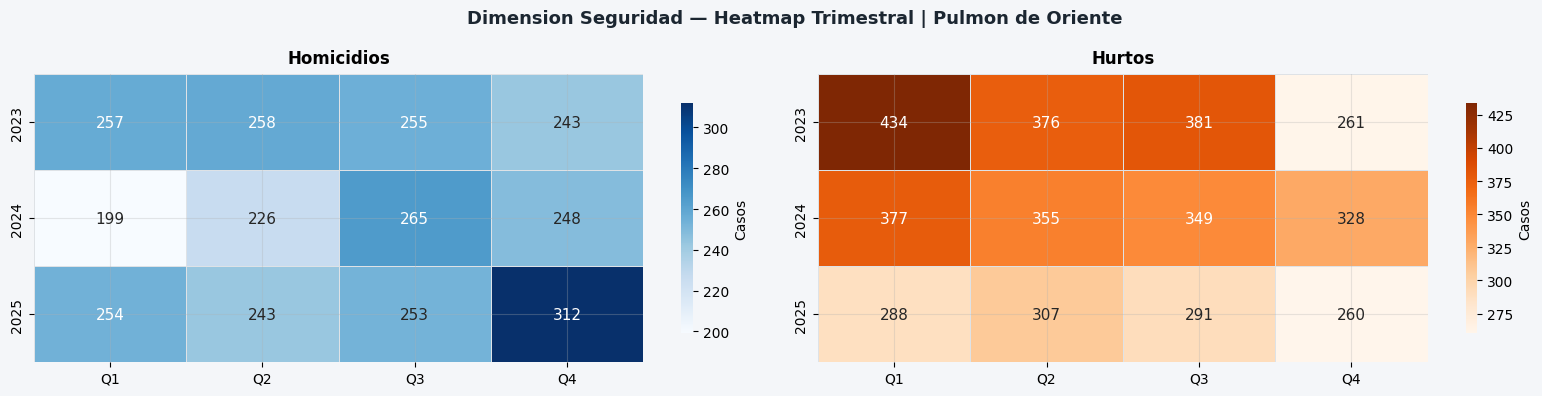

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle('Dimension Seguridad — Heatmap Trimestral | Pulmon de Oriente',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h, cmap_h in [
    (axes[0],'homicidios','Homicidios','Blues'),
    (axes[1],'hurtos','Hurtos','Oranges')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap_h,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig(IMG_DIR + 'itt_pulmon_heatmap_seg.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 10 — Heatmap: Dimension Cohesion Social (VIF)


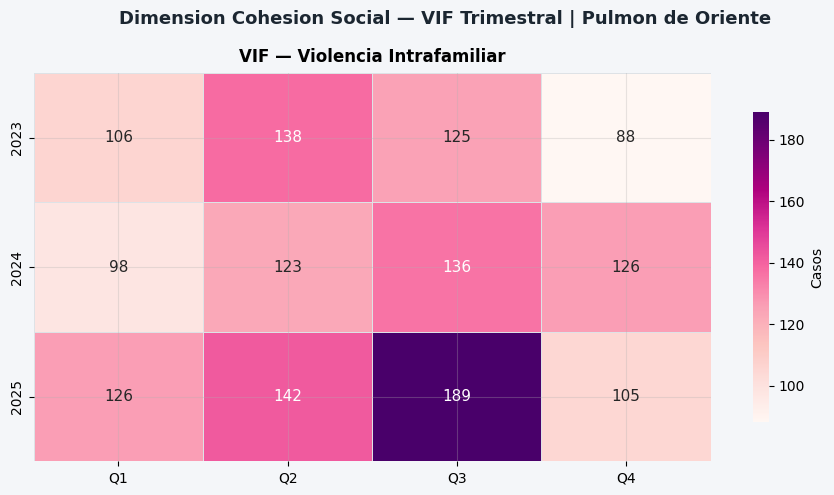

In [29]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
fig.suptitle('Dimension Cohesion Social — VIF Trimestral | Pulmon de Oriente',
             fontsize=13, fontweight='bold', color='#1B2631')
pivot = corr_trim.pivot(index='año', columns='trimestre', values='vif')
pivot.columns = ['Q1','Q2','Q3','Q4']
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdPu',
    linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
    cbar_kws={'label':'Casos','shrink':0.8})
ax.set_title('VIF — Violencia Intrafamiliar', fontweight='bold', pad=8)
ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig(IMG_DIR + 'itt_pulmon_heatmap_vif.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 11 — Evolucion trimestral: Seguridad


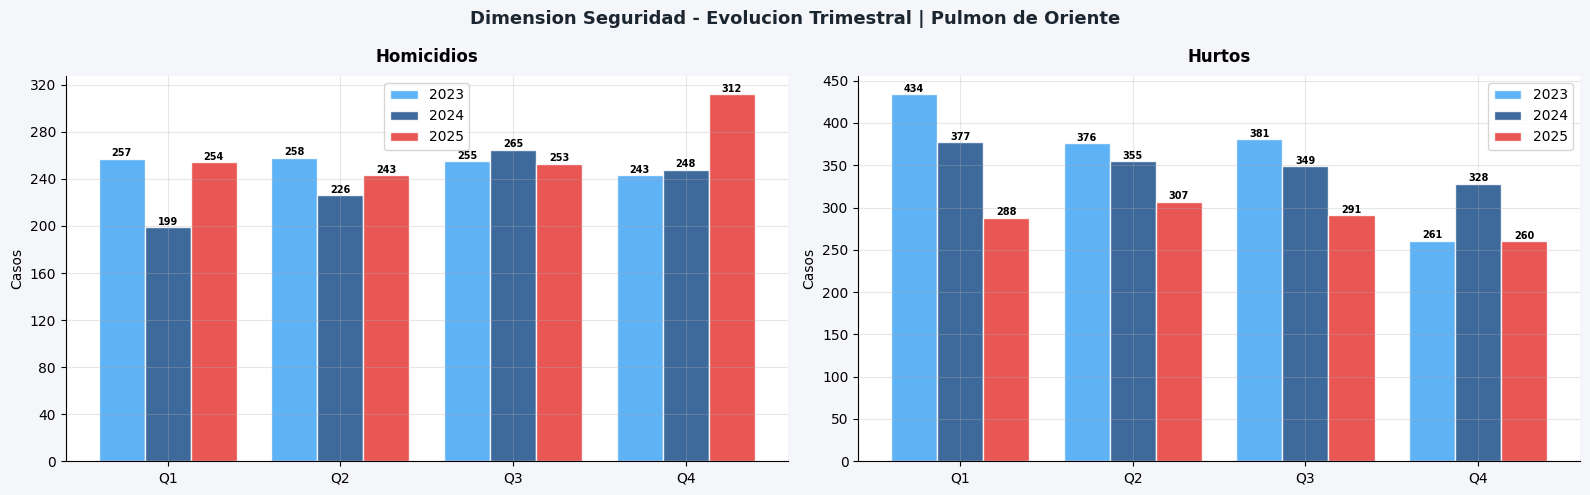

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
fig.suptitle('Dimension Seguridad - Evolucion Trimestral | Pulmon de Oriente',
             fontsize=13, fontweight='bold', color='#1B2631')
x = np.arange(4); n = len(ANIOS); w = 0.8/n
COLORES = ['#42A5F5','#1B4F8A','#E53935']
for ax, col, tp in [(axes[0],'homicidios','Homicidios'),(axes[1],'hurtos','Hurtos')]:
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim['año']==año][col].values
        offset = (idx-n/2+0.5)*w
        b = ax.bar(x+offset, vals, w, label=str(año), color=COLORES[idx%3], alpha=0.85, edgecolor='white')
        for bar in b:
            h = bar.get_height()
            if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.5, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=10)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR + 'itt_pulmon_seg_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 12 — Evolucion trimestral: Cohesion Social (VIF)


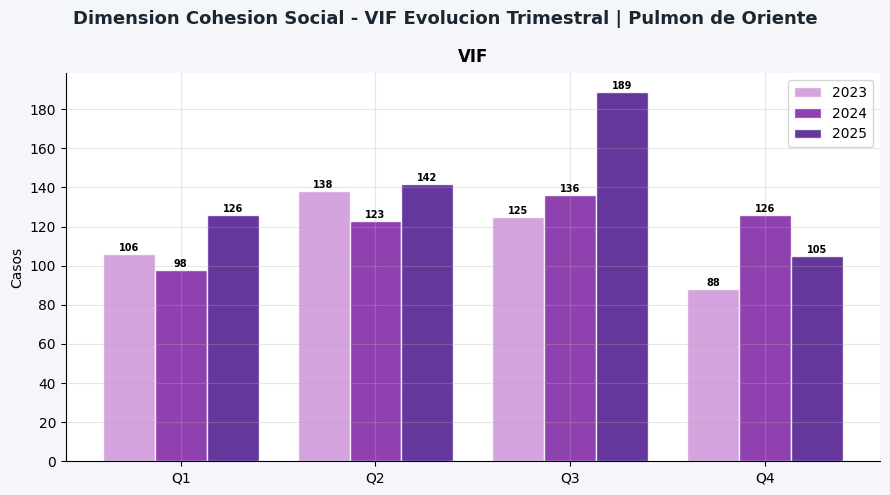

In [31]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
fig.suptitle('Dimension Cohesion Social - VIF Evolucion Trimestral | Pulmon de Oriente',
             fontsize=13, fontweight='bold', color='#1B2631')
x = np.arange(4); n = len(ANIOS); w = 0.8/n
CVIF = ['#CE93D8','#7B1FA2','#4A148C']
for idx, año in enumerate(ANIOS):
    vals = corr_trim[corr_trim['año']==año]['vif'].values
    offset = (idx-n/2+0.5)*w
    b = ax.bar(x+offset, vals, w, label=str(año), color=CVIF[idx%3], alpha=0.85, edgecolor='white')
    for bar in b:
        h = bar.get_height()
        if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.5, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('VIF', fontweight='bold', pad=8)
ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR + 'itt_pulmon_coh_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 13 — ITT Global y composicion por dimension


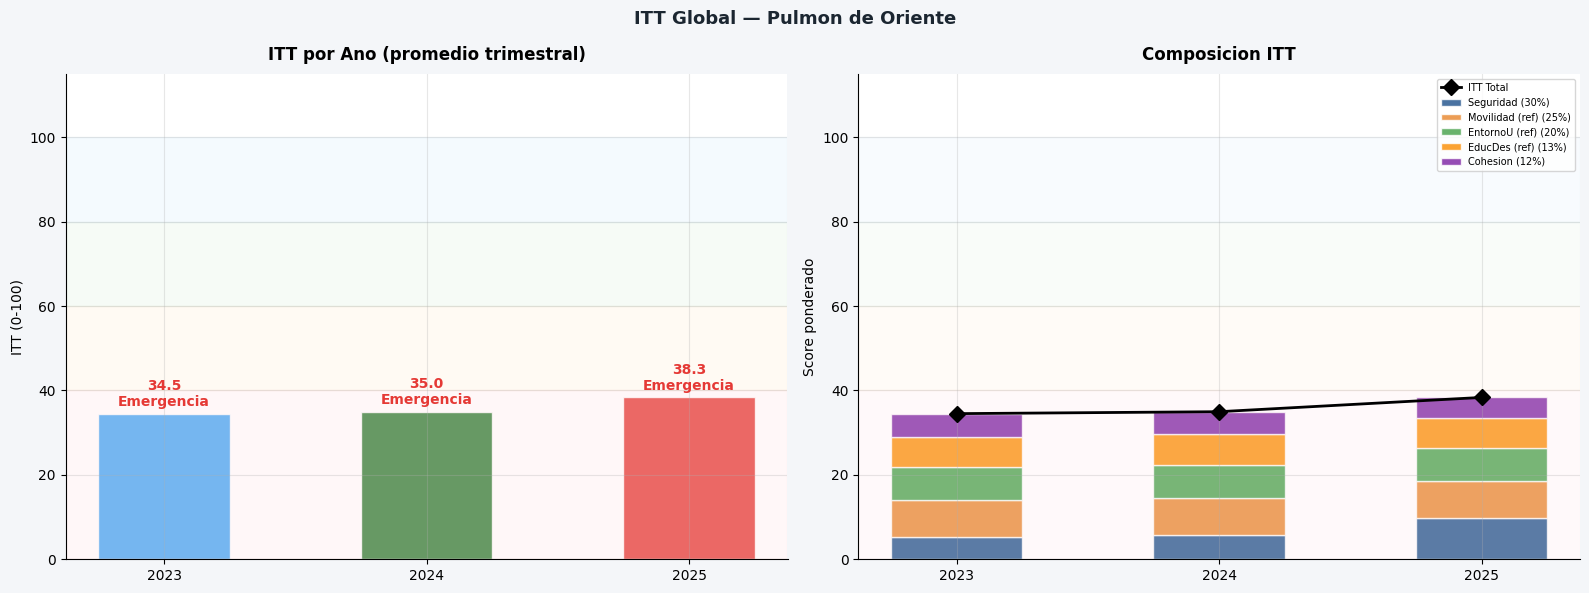

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('ITT Global — Pulmon de Oriente', fontsize=13, fontweight='bold', color='#1B2631')
COLORES_ITT = ['#42A5F5','#2E7D32','#E53935']
band_configs = [(0,40,'#FFCDD2','Emergencia'),(40,60,'#FFE0B2','Consolidacion'),
                (60,80,'#C8E6C9','Avance'),(80,100,'#BBDEFB','Transformacion')]

ax1 = axes[0]
bars = ax1.bar(ANIOS, base['ITT'], color=COLORES_ITT, alpha=0.85, edgecolor='white', width=0.5)
for bar, val, nivel in zip(bars, base['ITT'], base['nivel']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}\n{nivel}', ha='center', va='bottom',
        fontsize=10, fontweight='bold', color=NIVEL_COLORS.get(nivel,'#1B2631'))
for y0,y1,c,l in band_configs: ax1.axhspan(y0,y1, alpha=0.15, color=c)
ax1.set_title('ITT por Ano (promedio trimestral)', fontweight='bold', pad=10)
ax1.set_ylim(0,115); ax1.set_ylabel('ITT (0-100)'); ax1.set_xticks(ANIOS)

ax2 = axes[1]
dims = ['score_seguridad','score_movilidad','score_entorno_u','score_educ_des','score_cohesion']
dim_lbl = ['Seguridad','Movilidad (ref)','EntornoU (ref)','EducDes (ref)','Cohesion']
dim_p = [PESOS['Seguridad'],PESOS['Movilidad'],PESOS['EntornoU'],PESOS['EducDes'],PESOS['Cohesion']]
dim_c = [C_SEG, C_MOV, '#43A047', '#FB8C00', C_COH]
bottom = np.zeros(len(ANIOS))
for dim, lbl, peso, col in zip(dims, dim_lbl, dim_p, dim_c):
    vals = base[dim].values * peso
    ax2.bar(ANIOS, vals, bottom=bottom, label=f'{lbl} ({peso:.0%})', color=col, alpha=0.8, edgecolor='white', width=0.5)
    bottom += vals
ax2.plot(ANIOS, base['ITT'], 'D-', color='black', linewidth=2, markersize=8, label='ITT Total', zorder=5)
for y0,y1,c,l in band_configs: ax2.axhspan(y0,y1, alpha=0.1, color=c)
ax2.set_title('Composicion ITT', fontweight='bold', pad=10)
ax2.set_ylim(0,115); ax2.set_ylabel('Score ponderado'); ax2.set_xticks(ANIOS)
ax2.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.savefig(IMG_DIR + 'itt_pulmon_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 14 — Radar ITT: 5 dimensiones


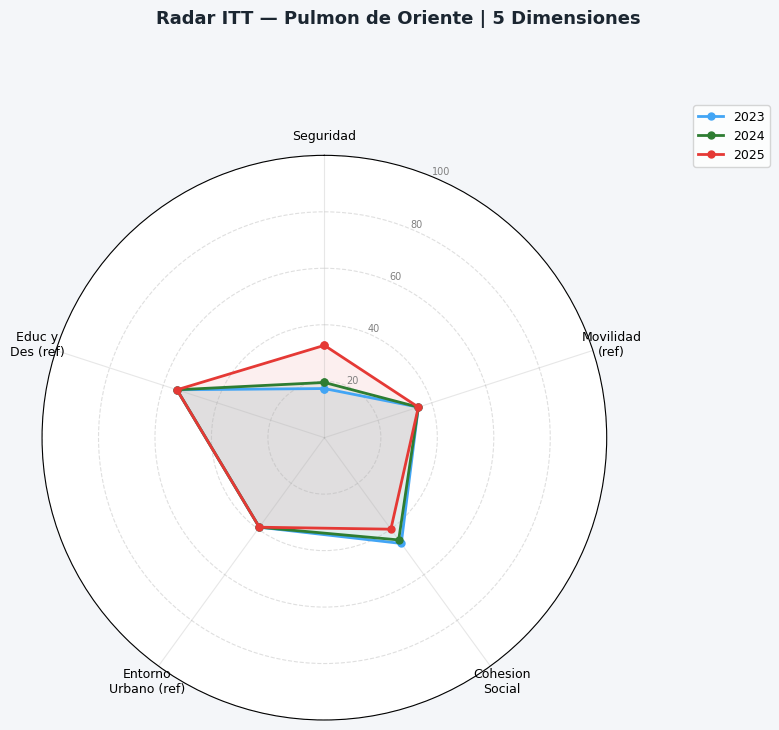

In [33]:
DIMS_LBL = ['Seguridad','Movilidad\n(ref)','Cohesion\nSocial','Entorno\nUrbano (ref)','Educ y\nDes (ref)']
N_DIMS = 5
angles = [i/N_DIMS*2*np.pi for i in range(N_DIMS)] + [0]
COLORES_R = ['#42A5F5','#2E7D32','#E53935']

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True), facecolor=BG)
fig.suptitle('Radar ITT — Pulmon de Oriente | 5 Dimensiones', fontsize=13, fontweight='bold', color='#1B2631')
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(DIMS_LBL, fontsize=9)
ax.set_ylim(0,100); ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=7, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

for idx, año in enumerate(ANIOS):
    row = base[base['año']==año].iloc[0]
    vals = [row['score_seguridad'],row['score_movilidad'],row['score_cohesion'],row['score_entorno_u'],row['score_educ_des']]
    vals_c = vals + [vals[0]]
    ax.plot(angles, vals_c, 'o-', color=COLORES_R[idx], linewidth=2, markersize=5, label=str(año))
    ax.fill(angles, vals_c, alpha=0.08, color=COLORES_R[idx])
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=9)
plt.tight_layout()
plt.savefig(IMG_DIR + 'itt_pulmon_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 15 — Exportar a Excel


In [34]:
EXPORT_PATH = IMG_DIR + 'ITT_Pulmon_Oriente.xlsx'
with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    base.round(2).to_excel(writer, sheet_name='ITT_Anual', index=False)
    corr_trim.round(2).to_excel(writer, sheet_name='Series_Trimestrales', index=False)

    # Datos estaticos
    est = pd.DataFrame({'Elemento':['Arboles','Sedes Educativas','CAI/MECAL'],
        'Cantidad':[len(raw_arb['features']),len(raw_sed['features']),len(raw_cai['features'])]})
    est.to_excel(writer, sheet_name='Datos_Estaticos', index=False)

    # Umbrales
    refs_df = pd.DataFrame([
        {'Indicador':ind,'ref_min':rmin,'ref_max':rmax,'Inverso':inv,'Descripcion':desc}
        for ind,(rmin,rmax,inv,desc) in REFS.items()
    ])
    refs_df.to_excel(writer, sheet_name='Umbrales_RefMinMax', index=False)

    # Metodologia
    met = pd.DataFrame({'Elemento':[
        'Indice','Zona','Periodo','Normalizacion',
        'Peso Seguridad','Peso Movilidad','Peso EntornoU','Peso EducDes','Peso Cohesion',
        'Movilidad ref','Entorno Urbano ref','Educ y Desarrollo ref','Vulnerabilidad ref','Rinas ref',
        'ITT Global','Nivel 1','Nivel 2','Nivel 3','Nivel 4'],
    'Descripcion':[
        'Indice de Transformacion Territorial',
        'Pulmon de Oriente — Cali',
        f'{ANIOS[0]}-{ANIOS[-1]}',
        'ref_min/ref_max fijos por indicador (trimestral)',
        f'{PESOS["Seguridad"]:.0%}',f'{PESOS["Movilidad"]:.0%}',
        f'{PESOS["EntornoU"]:.0%}',f'{PESOS["EducDes"]:.0%}',f'{PESOS["Cohesion"]:.0%}',
        f'Score fijo={REF_MOVILIDAD} (guia metodologica)',
        f'Score fijo={REF_ENTORNO_U} (guia metodologica)',
        f'Score fijo={REF_EDUC_DES} (guia metodologica)',
        f'{REF_VULNERABILIDAD} (Sec. Bienestar Social)',
        f'Score fijo={REF_RINAS} (no hay comparendos en ZIPs)',
        'ITT = 0.30*Seg + 0.25*Mov + 0.20*EntU + 0.13*EyD + 0.12*Coh',
        '0-40 Emergencia','40-60 Consolidacion','60-80 Avance','80-100 Transformacion']
    })
    met.to_excel(writer, sheet_name='Metodologia', index=False)

print(f'Exportado: {EXPORT_PATH}')
print('Hojas: ITT_Anual | Series_Trimestrales | Datos_Estaticos | Umbrales_RefMinMax | Metodologia')


Exportado: /content/itt_repos_cali/outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/ITT_Pulmon_Oriente.xlsx
Hojas: ITT_Anual | Series_Trimestrales | Datos_Estaticos | Umbrales_RefMinMax | Metodologia


## Celda 16 — Validar imagenes y push al repo
Verifica que las imagenes se generaron y las sube a GitHub.


In [35]:
import os, subprocess, platform

print("=" * 50)
print("VALIDACION DE IMAGENES GENERADAS")
print("=" * 50)
print(f"Carpeta: {IMG_DIR}")
if os.path.exists(IMG_DIR):
    png_files = [f for f in os.listdir(IMG_DIR) if f.endswith(".png")]
    print(f"Imagenes: {len(png_files)}")
    for f in sorted(png_files):
        size_kb = os.path.getsize(os.path.join(IMG_DIR, f)) / 1024
        print(f"  OK  {f} ({size_kb:.1f} KB)")

# Push solo en Colab
if platform.system() == "Linux" and os.path.exists("/content/itt_repos_cali"):
    print()
    print("=" * 50)
    print("PUSH DE IMAGENES AL REPOSITORIO")
    print("=" * 50)
    os.chdir("/content/itt_repos_cali")
    subprocess.getoutput("git config user.email \"colab@itt.local\"")
    subprocess.getoutput("git config user.name \"ITT Colab\"")
    print(subprocess.getoutput("git add outputs/IMAGENES_POR_ITT/"))
    print(subprocess.getoutput("git status --short"))
    result = subprocess.getoutput("git commit -m \"feat: imagenes ITT Pulmon de Oriente generadas desde Colab\"")
    print(result)
    if "nothing to commit" not in result:
        print(subprocess.getoutput("git push"))
else:
    print()
    print("En local: no se hace push automatico. Las imagenes quedan guardadas en IMG_DIR.")


VALIDACION DE IMAGENES GENERADAS
Carpeta: /content/itt_repos_cali/outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/
Imagenes: 11
  OK  itt_pulmon_Serie_T1_observada_para_Seguridad_2026.png (35.0 KB)
  OK  itt_pulmon_cards.png (93.0 KB)
  OK  itt_pulmon_coh_trim.png (51.9 KB)
  OK  itt_pulmon_global.png (78.8 KB)
  OK  itt_pulmon_heatmap_seg.png (85.5 KB)
  OK  itt_pulmon_heatmap_seguridad_trimestral.png (91.2 KB)
  OK  itt_pulmon_heatmap_vif.png (54.6 KB)
  OK  itt_pulmon_radar.png (148.4 KB)
  OK  itt_pulmon_score_seguridad_t1.png (42.8 KB)
  OK  itt_pulmon_seg_trim.png (79.3 KB)
  OK  itt_pulmon_seguridad_t1_comparativo.png (56.1 KB)

PUSH DE IMAGENES AL REPOSITORIO

M  outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/ITT_Pulmon_Oriente.xlsx
M  outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/itt_pulmon_cards.png
M  outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/itt_pulmon_coh_trim.png
M  outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/itt_pulmon_global.png
M  outputs/IMAGENES_POR_ITT/itt_pulmon_oriente/i